# 3MTT Capstone Project
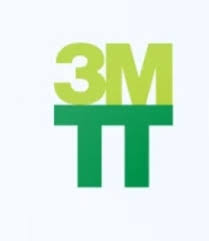

Riverine communities need flood-risk awareness.

This model classifies a community's flood risk from environmental features.

Feature input; risk class; key factors; evaluation

## Ero River Catchment Area

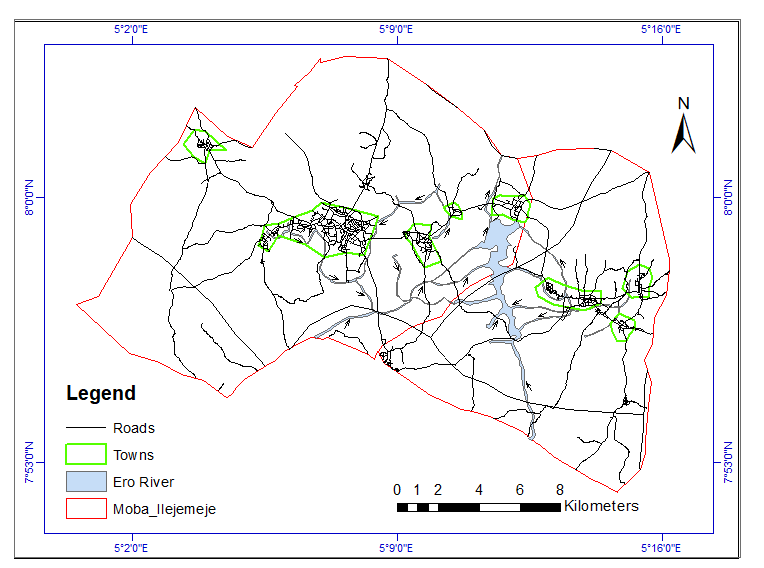

Ero River is in Moba and Ilejemeje LGAs serving at least seventen communities in Ekiti State

# Preparing the Dataset

In 2025, two PhD candidates, Mr. Andrew ToluTaiwo and Mr. Thomas Olonisaye, of the University of Lagos did a study on flood susceptibility mapping in Ero River catchment area in Ekiti State, Nigeria. They collected the Flood Predictors dataset used in this project.

###**Flood Predictors**



Flood Predictors are environmental features, topographic and hydrologic variables, that influence the occurence or magnitude of flooding incidents.  


- **lon: Longitude.** Longitude coordinate of a location

- **lat: Latitude.** Latitude coordinate of a location

- **dist_ri: Distice from River.** Distance in metres from the nearest river

- **elev: Elevation.** Height above mean sea level of the location

- **NDVI: Normalized Difference Vegetation Index.** A measure of occurence of vegetation in the location.

- **NDWI: Normalized Difference Water Index.** A measure of the wetness of the soil.

- **rain: Rainfall.** Amount of rainfall in the region

- **NDBI: Normalized Difference Building Index.** Differentiates between built-up areas and non built-up areas.

- **LULC: Land Use Land Cover.** Land Use refers to how humans use land for various purposes. Land Cover refers to the materials that cover a part of the earth's surface. 0-Water body, 1-Farmland, 2-Forest, 3-Builtup, 4-Bareground

- **rock_por: rock porosity.** Form and porousness of sub-surface rock.

- **rock_perm: Rock Permeability.** Rock permeability affects runoff.

- **Soil_por: Soil Porosity.** Form and porousness of soil.

- **soil_perm: Soil Permeability.** Soil permeability affects runoff.

**flood_risk: Flood Risk Class.** A location's susceptibility to flooding. This is the target variable.



In [2]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# supress warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
## Load the data
flood_data = pd.read_csv('flood_prediction_data2.csv')
flood_data = flood_data.drop(columns=['Unnamed: 0'])

### A little bit of data exploration and cleaning

In [5]:
## Explore the first 5 rows
flood_data.head(5)

,lon,lat,dist_ri,elev,NDVI,NDWI,rain,NDBI,LULC,rock_por,rock_perm,soil_por,soil_perm,flood_risk
0,5.1572,8.0133,5,517,0.55,-0.66,259.75,-0.07,1,0.05,1.000000e-16,0.55,0.001,1
1,5.1707,8.0147,5,519,0.48,-0.55,255.58,0.01,1,0.05,1.000000e-16,0.55,0.001,1
2,5.1649,8.0072,5,531,0.47,-0.68,254.91,-0.01,1,0.05,1.000000e-16,0.55,0.001,1
3,5.1810,8.0033,5,526,0.48,-0.60,254.00,0.00,1,0.05,1.000000e-16,0.55,0.001,1
4,5.1832,8.0108,5,514,0.42,-0.63,254.00,0.04,4,0.05,1.000000e-16,0.55,0.001,1


In [6]:
## Display the columns names
print(flood_data.columns)

Index(['lon', 'lat', 'dist_ri', 'elev', 'NDVI', 'NDWI', 'rain', 'NDBI', 'LULC',
       'rock_por', 'rock_perm', 'soil_por', 'soil_perm', 'flood_risk'],
      dtype='object')


#### Missing values

In [7]:
# Where are there missing values?
missing_vals = flood_data.isna().sum()
missing_vals.index[missing_vals>0]
missing_vals

,0
lon,0
lat,0
dist_ri,0
elev,0
NDVI,0
NDWI,0
rain,0
NDBI,0
LULC,0
rock_por,0


In [8]:
# print important statistics
flood_data.describe()

,lon,lat,dist_ri,elev,NDVI,NDWI,rain,NDBI,LULC,rock_por,rock_perm,soil_por,soil_perm,flood_risk
count,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,722.000000,7.220000e+02,722.000000,722.000000,722.000000
mean,5.152463,7.956060,3.130194,546.055402,0.569889,-0.618352,306.156884,-0.077271,3.008310,0.042976,5.886427e-04,0.547742,0.000260,0.440443
std,0.066029,0.033578,1.634307,21.812013,0.135047,0.064207,33.879976,0.065769,1.296507,0.016275,1.931140e-03,0.045554,0.000350,0.496784
min,5.030230,7.872770,1.000000,477.000000,0.130000,-0.740000,0.000000,-0.200000,0.000000,0.004600,1.000000e-16,0.470000,0.000042,0.000000
25%,5.090160,7.933805,1.000000,529.000000,0.490000,-0.670000,283.990000,-0.130000,2.250000,0.050000,1.000000e-16,0.550000,0.000118,0.000000
50%,5.153855,7.956460,4.000000,548.000000,0.565000,-0.620000,312.355000,-0.080000,4.000000,0.050000,1.000000e-16,0.580000,0.000118,0.000000
75%,5.209290,7.981400,5.000000,562.000000,0.670000,-0.570000,332.767500,-0.030000,4.000000,0.050000,1.000000e-15,0.580000,0.000118,1.000000
max,5.269120,8.029350,5.000000,603.000000,0.820000,-0.380000,361.240000,0.090000,4.000000,0.050000,1.600000e-02,0.580000,0.001000,1.000000


Investigating Feature Correlation with `suscep` for Data Leakage

,flood_risk
flood_risk,1.000000
dist_ri,0.780005
soil_por,0.492618
NDBI,0.448793
lon,0.423115
soil_perm,0.161554
lat,0.144471
rock_por,-0.012874
rock_perm,-0.019067
NDWI,-0.060620


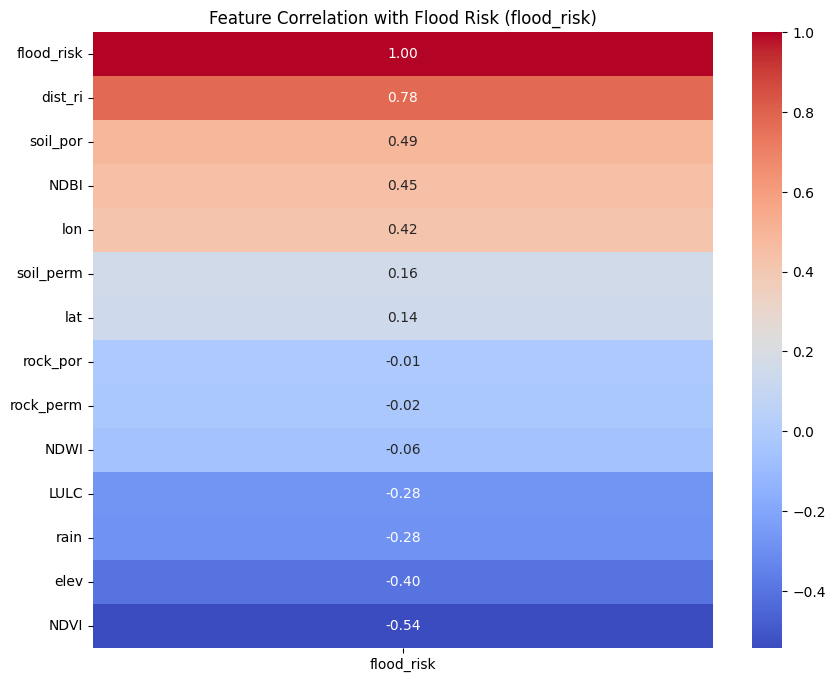

In [9]:
correlation_matrix = flood_data.corr()
suscep_correlations = correlation_matrix['flood_risk'].sort_values(ascending=False)
display(suscep_correlations)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['flood_risk']].sort_values(by='flood_risk', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Flood Risk (flood_risk)')
plt.show()

## Training, Validation and Testing Splits

We often split the dataset into three different chunks:

1. **Training data**: the data we build our models on.
2. **Validation data**: the data we tune hyperparameters on.
3. **Testing data**: the data we use to obtain a final estimate of performance.

The validation set is like an 'intermediate' estimate of performance. If we didn't use the validation set for this purpose, the only way of selecting the best model from a model class would be to look at its performance on the training set or the testing set.

`train_test_split` in scikit-learn provides an easy way of creating these data partitions. Let's start by just creating training/testing sets. We'll get to parameter tuning in a minute.

In [10]:
from sklearn.model_selection import train_test_split

X = flood_data.drop(columns=['flood_risk'], axis=1)
y = flood_data['flood_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.70, random_state = 1)

print("Training Size = %d" % X_train.shape[0]) # To print integers, we can pass '%d' into our print statement
print("Testing Size = %d" % X_test.shape[0])

Training Size = 505
Testing Size = 217


The sklearn.preprocessing facilitates the transition from 'raw' data to a standard format for algorithm training.

Among such algorithms, we find:

**Standardization**

Standardization is the first type of transformation to consider, as a large number of machine learning/statistical algorithms assume that the data they operate on is normally distributed. Standardization is expressed as:

\begin{equation}
\frac{x_{i} - \text{mean}(x)}{\text{std}(x)}
\end{equation}

In practice, the shape of the distribution to work with is ignored and the transformation is simply performed by removing the mean and scaling by the standard deviation.

Note: This is not recommended if the histogram of the target variable is far from Gaussian. In such cases, alternative transformations will be reviewed.

**Min-Max Scaling**

A good alternative to the previous method is range scaling, which is expressed as:

\begin{equation}
\frac{x_{i} - \min(x)}{\max (x)-\min (x)}
\end{equation}

for $x$ being the column to treat, and $x_i$ the element to transform. This transformation allows the data to range between 0 and 1 and can be used when the distribution of the data does not meet the normality assumption. Note that this transformer is affected by the presence of outliers.


In [11]:
### The "manual" way ###

# Normalization
X_train_normalized = (X_train - X_train.min())/(X_train.max()-X_train.min())
X_test_normalized = (X_test - X_train.min())/(X_train.max()-X_train.min())

# Standardization
X_train_standardized = (X_train - X_train.mean())/X_train.std()
X_test_standardized = (X_test - X_train.mean())/X_train.std()

## Logistic Regression
Logistic regression is part of the class of generalized linear models (GLMs), which build directly on top of linear regression. These models take the linear fit and map it through a non-linear function.

Specifically, logistic regression is used when the dependent variable is **binary** (e.g. true/false, yes/no, 0/1) and the goal is to find the relationship between one or more independent variables and the probability of the dependent variable being true or 1.

For logistic regression, the function $f(\cdot)$ is given by $\displaystyle f(z) = \frac{1}{1+\exp(-z)}$ (the *logistic function* - also called the *sigmoid function*).


Where:

- $f(z)$ is the probability of the dependent variable being true or 1
- z is the linear combination of the independent variables and the coefficients of the model:
$\displaystyle z = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n$




We use a grid search to tune regularization parameters:
1. Define a parameter grid
2. Initialize a GridSearchCV object with the tuning grid and other fixed parameters
3. Fit the model!

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the grid that we want to search over
param_grid = {'C': np.arange(0.001, 1, 0.05),
              'penalty': ['l2','l1'],
              'solver': ['liblinear']}

# Define the parameters for the model
gs = GridSearchCV(LogisticRegression(random_state=42, max_iter = 1000),
                  return_train_score=True,
                  param_grid=param_grid,
                  scoring='roc_auc',
                  cv=5, verbose = 0)
## Fit the model
random.seed(42)
gs.fit(X_train_standardized, y_train)
m_lr = gs.best_estimator_
print("Best parameters: ", gs.best_params_)

Best parameters:  {'C': np.float64(0.15100000000000002), 'penalty': 'l1', 'solver': 'liblinear'}


In [13]:
# Let's look at the coefficients
coef_output = pd.DataFrame({'feature':X_train_standardized.columns,
              'coefficient':m_lr.coef_[0]})

print("Number of zeros: %d" % (coef_output.query('coefficient == 0').shape[0]))
coef_output.sort_values('coefficient')

Number of zeros: 8


,feature,coefficient
4,NDVI,-1.382105
3,elev,-0.999582
5,NDWI,-0.504173
6,rain,-0.169481
0,lon,0.000000
1,lat,0.000000
7,NDBI,0.000000
8,LULC,0.000000
12,soil_perm,0.000000
9,rock_por,0.000000


We can now explore out-of-sample performance. Ultimately, we want to predict whether or not a location is flooded. Logistic regression gives a probability that each location is flooded. This gives us flexibility in the way we predict. The most natural thing would be to predict that any location with predicted probability above 0.5 is flooded, and any location with predicted probability below 0.5 is not flooded. But if we want to be certain, may want to use a cutoff value of 0.9 rather than 0.5. In fact, we could choose any cutoff value and have a corresponding prediction model.

This is where AUC comes in. For every cutoff, we'll plot the *false positive rate* (FPR) against the *true positive rate* (TPR) and then take the area under this curve.

Also known as **Sensitivity** or **Recall**, TPR measures the proportion of actual positives that are correctly identified by the model.

$
TPR = \frac{TP}{TP + FN}
$

Where:
- $ TP $ (True Positives) = Correctly predicted positive cases.
- $ FN $ (False Negatives) = Actual positive cases that were incorrectly predicted as negative.

FPR measures the proportion of actual negatives that are incorrectly identified as positive by the model.

$
FPR = \frac{FP}{FP + TN}
$

Where:
- $ FP $ (False Positives) = Incorrectly predicted positive cases.
- $ TN $ (True Negatives) = Correctly predicted negative cases.

**High TPR** means the model correctly identifies most of the positive cases.
**Low FPR** means the model makes fewer false alarms by incorrectly classifying negatives as positives.

Train AUC: 0.980
Test AUC: 0.987


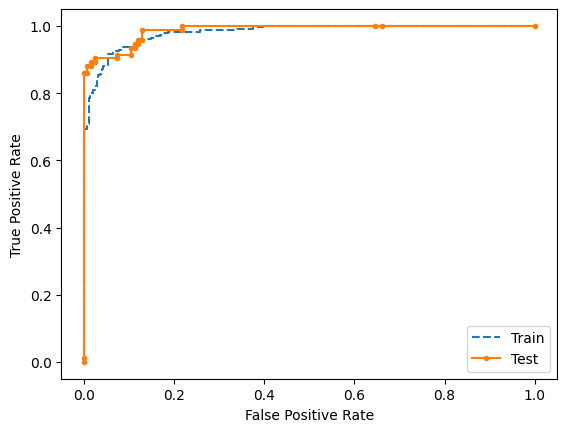

In [14]:
train_pred = m_lr.predict_proba(X_train_standardized)[:,1]
test_pred = m_lr.predict_proba(X_test_standardized)[:,1]

print("Train AUC: %.3f" % metrics.roc_auc_score(y_train, train_pred))
print("Test AUC: %.3f" % metrics.roc_auc_score(y_test, test_pred))

train_fpr, train_tpr, _ = metrics.roc_curve(y_train, train_pred)
test_fpr, test_tpr, _ = metrics.roc_curve(y_test, test_pred)

# plot the roc curve for the model
plt.plot(train_fpr, train_tpr, linestyle='--', label='Train')
plt.plot(test_fpr, test_tpr, marker='.', label='Test')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

### Confusion Matrix Analysis

Train Accuracy: 0.931
Test Accuracy: 0.940


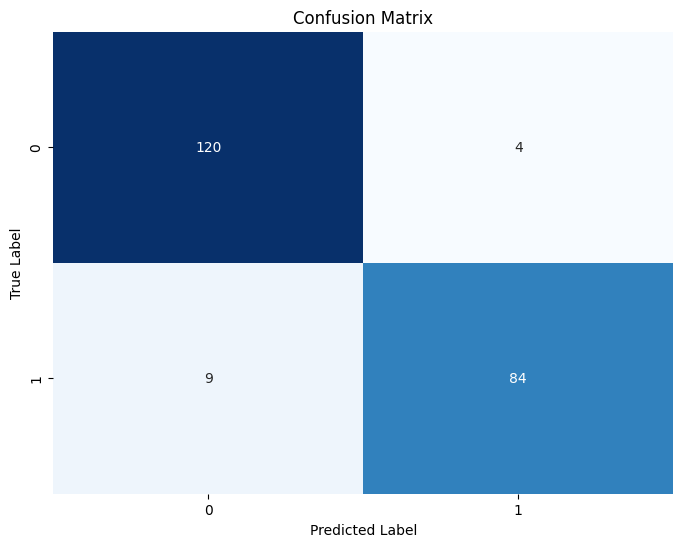

In [15]:
t = 0.5
print("Train Accuracy: %.3f" %  metrics.accuracy_score(y_train, train_pred > t))
print("Test Accuracy: %.3f" %  metrics.accuracy_score(y_test, test_pred > t))

# If we wanted to get all of the elements of the confusion matrix, we could pull them like this:
tn, fp, fn, tp = metrics.confusion_matrix(y_test, test_pred > t).ravel()

# Plot the confusion matrix on the test set
cm = metrics.confusion_matrix(y_test, test_pred > t)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

From these numbers, we can see that the model is performing quite well, with a higher number of true positives and true negatives. The number of false negatives (4) is lower than false positives (9), which means the model is less likely to miss actual flood-susceptible locations, which is often a critical aspect in flood prediction tasks.

In [16]:
np.mean(1-y_train)

np.float64(0.5544554455445545)

**Note:** The code np.mean(1-y_train) calculates the proportion of instances in the training set (y_train) where the flood susceptibility (suscep) is 0. In other words, it tells us the percentage of training samples that are not susceptible to flooding.

The result, 0.5544554455445545 (approximately 55%), indicates that about 55% of the training data points represent locations that are not susceptible to flooding. This value can also be considered the baseline accuracy if a model were to simply predict 'no flood' for every instance, without any learning.



### K-Fold Cross-Validation for Robust Accuracy Estimate

In [17]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the logistic regression model
cv_scores = cross_val_score(m_lr, X, y, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.3f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.3f}")

Cross-validation accuracy scores: [1.         0.90344828 0.97916667 0.79861111 0.70138889]
Mean cross-validation accuracy: 0.877
Standard deviation of cross-validation accuracy: 0.112


Mean cross-validation accuracy: 0.877

This is the average of the accuracy scores from all 5 folds. It gives an overall, more generalized estimate of how well the model is expected to perform on unseen data. An average of 87.7% is quite good.

Standard deviation of cross-validation accuracy: 0.112. This tells how much the individual fold scores deviate from the mean. A higher standard deviation (like 0.112 in this case, relative to the mean) suggests that the model's performance is somewhat inconsistent across different data subsets.

### Flood Risk Categories

In [18]:
import numpy as np

# Standardize the entire X dataset using the mean and std from X_train
X_standardized = (X - X_train.mean()) / X_train.std()

# Ensure X is the full feature set as used for training
# Get probability predictions from the best logistic regression model for the full dataset
flood_probabilities = m_lr.predict_proba(X_standardized)[:, 1]

# Define the risk classification function
def classify_flood_risk(probability):
    if 0.00 <= probability <= 0.20:
        return 'Low Flood-Risk'
    elif 0.21 <= probability <= 0.45:
        return 'Moderate Flood-Risk'
    elif 0.46 <= probability <= 0.70:
        return 'High Flood-Risk'
    elif 0.71 <= probability <= 1.00:
        return 'Very High Flood-Risk'
    else:
        return 'Unknown'

# Create a copy of the original flood_data to add new columns
flood_data_classified = flood_data.copy()

# Add probability and risk classification to the DataFrame
flood_data_classified['flood_probability'] = flood_probabilities
flood_data_classified['flood_risk_category'] = flood_data_classified['flood_probability'].apply(classify_flood_risk)

# Display the first few rows with the new columns
print("Flood data with risk classification:")
display(flood_data_classified)

# Save the results to a CSV file
output_csv_path = 'flood_risk_classified_data.csv'
flood_data_classified.to_csv(output_csv_path, index=False)
print(f"Classified flood risk data saved to '{output_csv_path}'")

Flood data with risk classification:


,lon,lat,dist_ri,elev,NDVI,NDWI,rain,NDBI,LULC,rock_por,rock_perm,soil_por,soil_perm,flood_risk,flood_probability,flood_risk_category
0,5.15720,8.01330,5,517,0.55,-0.66,259.75,-0.07,1,0.0500,1.000000e-16,0.55,0.001000,1,0.982995,Very High Flood-Risk
1,5.17070,8.01470,5,519,0.48,-0.55,255.58,0.01,1,0.0500,1.000000e-16,0.55,0.001000,1,0.978893,Very High Flood-Risk
2,5.16490,8.00720,5,531,0.47,-0.68,254.91,-0.01,1,0.0500,1.000000e-16,0.55,0.001000,1,0.988002,Very High Flood-Risk
3,5.18100,8.00330,5,526,0.48,-0.60,254.00,0.00,1,0.0500,1.000000e-16,0.55,0.001000,1,0.980438,Very High Flood-Risk
4,5.18320,8.01080,5,514,0.42,-0.63,254.00,0.04,4,0.0500,1.000000e-16,0.55,0.001000,1,0.995130,Very High Flood-Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717,5.13083,7.94538,4,531,0.66,-0.60,333.05,-0.14,4,0.0046,3.000000e-03,0.58,0.000118,0,0.531309,High Flood-Risk
718,5.12168,7.94011,3,533,0.58,-0.56,333.22,-0.11,4,0.0046,3.000000e-03,0.58,0.000118,0,0.311549,Moderate Flood-Risk
719,5.13720,7.93401,4,549,0.61,-0.60,333.00,-0.10,4,0.0046,3.000000e-03,0.58,0.000118,0,0.451737,Unknown
720,5.21341,7.90935,4,525,0.64,-0.61,361.00,-0.08,3,0.0500,1.000000e-16,0.58,0.000118,0,0.634333,High Flood-Risk


Classified flood risk data saved to 'flood_risk_classified_data.csv'


### Spatial Distribution of flood-risk categories.







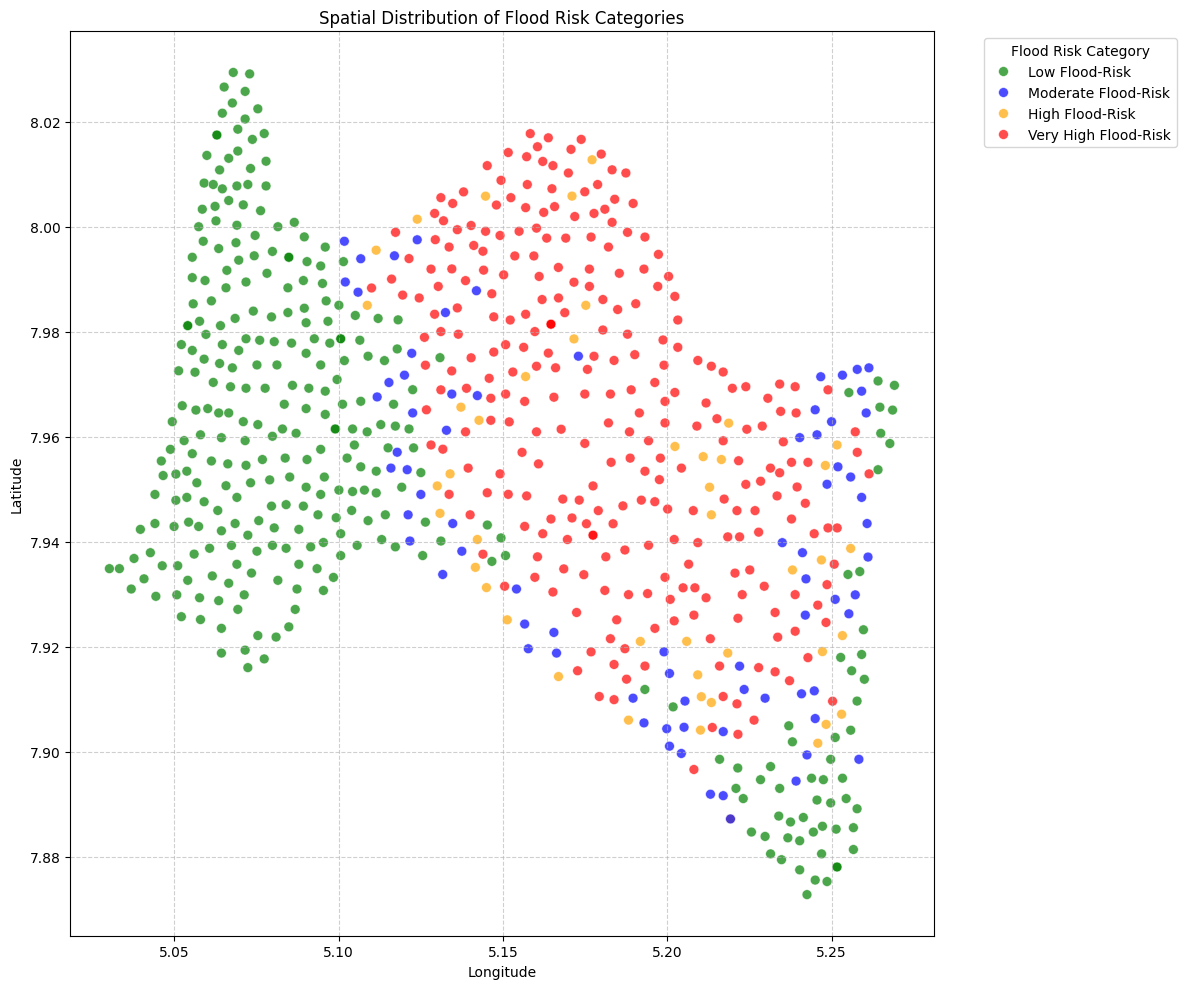

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a custom color palette to ensure distinct colors for each risk category
# and order them logically (e.g., green for low, red for very high)
color_palette = {
    'Low Flood-Risk': 'green',
    'Moderate Flood-Risk': 'blue',
    'High Flood-Risk': 'orange',
    'Very High Flood-Risk': 'red'
}

# Ensure the categories are ordered for consistent plotting and legend
risk_order = ['Low Flood-Risk', 'Moderate Flood-Risk', 'High Flood-Risk', 'Very High Flood-Risk']
flood_data_classified['flood_risk_category'] = pd.Categorical(
    flood_data_classified['flood_risk_category'], categories=risk_order, ordered=True
)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=flood_data_classified,
    x='lon',
    y='lat',
    hue='flood_risk_category',
    palette=color_palette,
    s=50, # Size of the points
    alpha=0.7, # Transparency of the points
    edgecolor='w', # White edge for better distinction
    linewidth=0.5 # Line width of the edge
)

plt.title('Spatial Distribution of Flood Risk Categories')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Flood Risk Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Number of locations in the floo_risk categories

In [20]:
print('Number of locations in each flood risk category:')
display(flood_data_classified['flood_risk_category'].value_counts().sort_index())

Number of locations in each flood risk category:


,count
flood_risk_category,
Low Flood-Risk,314
Moderate Flood-Risk,76
High Flood-Risk,44
Very High Flood-Risk,277


This distribution of flood risk categories provides valuable insights into the flood risk of the evaluated locations:

*   **Low Flood-Risk**: These locations have a low probability of flooding, suggesting they are relatively safe. For these areas, standard preventative measures might suffice, and resources can be allocated elsewhere.

*   **Moderate Flood-Risk**: These areas show a noticeable but not extreme probability of flooding. They might require regular monitoring and basic flood preparedness plans. Future development in these areas should consider drainage and infrastructure to mitigate potential risks.

*   **High Flood-Risk**: Locations in this category have a significant chance of experiencing floods. These areas warrant more immediate attention, including early warning systems, robust flood defenses, and strict building codes. Community awareness and evacuation plans are crucial here.

*   **Very High Flood-Risk**: These are the most vulnerable locations, with a very high likelihood of flooding. Urgent and comprehensive flood mitigation strategies are needed, potentially including relocation considerations, major infrastructure projects, and stringent land-use planning. These areas could be prioritized for immediate interventions and resource allocation.

This classification is a powerful tool for urban planners, emergency services, and residents to make informed decisions regarding development, resource allocation, and safety measures in the Ero River catchment area.

## Conclusion

This project successfully developed and evaluated a Logistic Regression model for classifying flood risk in the Ero River catchment area based on various environmental features. By leveraging detailed geospatial and environmental data, the model provides valuable insights into the flood susceptibility of 722 locations.

### Implications:

The generated flood risk map and classifications can serve as a crucial tool for:

*   **Urban Planning**: Informing decisions on new developments and infrastructure projects to minimize exposure to flood hazards.
*   **Emergency Management**: Guiding the deployment of resources, establishment of early warning systems, and planning of evacuation routes.
*   **Community Awareness**: Educating residents about their specific flood risk and promoting preparedness measures.

### Key Takeaways

*   **Logistic Regression is Effective for Flood Risk Classification**: The model demonstrated strong predictive performance (AUC ~0.98), indicating its suitability for this binary classification task.
*   **Importance of Data Preprocessing**: Standardizing the features was crucial for optimal model training and accurate predictions.
*   **Cross-Validation for Robust Evaluation**: K-fold cross-validation provided a more reliable estimate of the model's generalization ability, highlighting both its average performance and variability.
*   **Spatial Analysis is Key for Actionable Insights**: Visualizing flood risk categories on a map transforms model outputs into practical information for stakeholders like urban planners and emergency services.
*   **Feature Importance**: Features like 'dist_ri' (distance from river), 'NDVI', 'elev', 'NDWI', and 'NDBI' were identified as significant predictors, aligning with hydrological understanding of flood susceptibility.
*   **Categorization Aids Decision-Making**: Translating probabilities into distinct risk categories (Low, Moderate, High, Very High) simplifies complex model outputs for non-technical users, facilitating targeted interventions and resource allocation.